In [1]:
import numpy as np
from matplotlib import pyplot as plt
import time

---
<h1 align="center">Genetic Algorithm Implementation</h1>   

---

# Initial Population
creates pop_size of random permutations 

In [2]:
def initial_Population(n, pop_size, rng):
    
    indices = list(range(n))

    # Random permutation of indices
    init_pop = np.array([
        rng.permutation(indices) for _ in range(pop_size)
    ])

    return init_pop

# Fitness Function
uses inverse of Total distance to make minimization into maximization problem

In [3]:
def fitness_of(c, dist_matrix):
    Total_distance = 0
    
    for i in range(1,n):
        prev_point = c[i-1]
        next_point = c[i]

        # Distance between two consecutive points in the chromosome
        Total_distance += dist_matrix[prev_point][next_point] 

    # return to the start point
    Total_distance += dist_matrix[c[-1]][c[0]]
    return 1 / Total_distance
    

# Crossover
Uses Ordered Crossover. Puts a random chunk of the first parent in the child and fills the left part with other parent by keeping the order 

In [4]:
def crossover(parent_a, parent_b, rng):
    
    n = len(parent_a)

    # Empty array for child
    child = np.array([-1] * n)
    
    # Keeps used indices
    used = set() 

    # Place a random part of the first parent in child
    shared_range = rng.choice(n, size=2, replace=False)
    # Put the smaller one first
    shared_range.sort()

    for i in range(shared_range[0],shared_range[1]):
        child[i] = parent_a[i]
        used.add(parent_a[i])
    
    # Fill remaining part with the second parent keeping its order
    p_ptr = 0 # Parent pointer 
    for i in range(0,n):
        # If was not filled with parent_a 
        if child[i] == -1:

            # moves forward to find the first not used point in parent_b 
            while parent_b[p_ptr] in used:
                p_ptr += 1
            
            # Places the first unused point
            child[i] = parent_b[p_ptr]
            p_ptr += 1
            # point will not be seen again so it won't be necessary to add it into used set 

    return child

# Mutation
Using Inversion Mutation, selects a random range within the chromosome and reverses the order of its elements.

In [5]:
def Mutate(c, rng):
        
    n = len(c)

    # Choose random chunk 
    rev_range = rng.choice(n, size=2, replace=False)
    # Put the smaller one first
    rev_range.sort()
    start, end = rev_range[0], rev_range[1]
    
    # Reverse the order of elements
    c[start : end + 1] = c[start : end + 1][::-1]
    

# The Main Evolutionary Loop

generates initial population 

then
For each generation, until reaching the limit given by user:
   1. Evaluate Fitness: Calculate 1/distance for all chromosomes.
   2. Track Champion: Log the all-time best route and fitness score.
   3. Selection: Run two tournaments to pick Parent A and Parent B.
   4. Crossover: Combine parents via Ordered Crossover to make children.
   5. Mutation: Flip random path segments via Inversion Mutation (1-5% chance).
   6. Replace: Overwrite the old population with the new generation.   

In [6]:
def Evolve(n, population_size, dist_matrix, reps, tournament_size, mutation_chance = 0.05, rng= None):
    if rng is None:
        rng = np.random.default_rng()

    population = initial_Population(n,population_size,rng) 

    pop_size = population.shape[0] # Populatio size   
    fittests = [] # The fittest chromosome from each generation 
    
    gen_i = 0 # counter
    while gen_i < reps:

        # Fitness of every chromosome in the population 
        fitness = np.array([fitness_of(c,dist_matrix) for c in population])

        # Find the fittest of current generation 
        fittest_idx = np.argmax(fitness)
        fittests.append(population[fittest_idx])
            
        # Create the next generation same size as current one
        next_generation = []
        next_generation.append(population[fittest_idx]) # Keep the best anwser
        while len(next_generation) < pop_size: 
            
            # -- First parent --

            # chooses random chromosomes
            competitioners = rng.choice(population, size=tournament_size, replace=False)
            f = np.array([fitness_of(c,dist_matrix) for c in competitioners]) # Calculate their fitness

            # Choose the winner as parent
            parent_a = competitioners[np.argmax(f)]

            # -- Second parent --
            
            parent_b = parent_a
            tries = 0 
            # loop to prevent choosing a single chromosome as both parents 
            while np.array_equal(parent_a, parent_b) and tries < 5:
                # chooses random chromosomes
                competitioners = rng.choice(population, size=tournament_size, replace=False)
                f = np.array([fitness_of(c,dist_matrix) for c in competitioners]) # Calculate their fitness

                # Choose the winner as parent
                parent_b = competitioners[np.argmax(f)]
                
                tries += 1

            # -- Crossover --

            child_a = crossover(parent_a, parent_b, rng)
            child_b = crossover(parent_b, parent_a, rng)

            # -- Mutation --

            if (rng.random() <= mutation_chance):
                Mutate(child_a, rng)
            next_generation.append(child_a)

            if (rng.random() <= mutation_chance):
                Mutate(child_b, rng)
            if len(next_generation) < pop_size: 
                next_generation.append(child_a)

        gen_i += 1
        population = np.array(next_generation)

    return fittests

---
<h1 align="center">Test and Results</h1>   

---

# Generating Random Points

generate "NUMBER_OF_POINTS" points in the chosen limit and save it in "DESTINATION_FILE"

In [7]:
DESTINATION_FILE = "50points.csv"
NUMBER_OF_POINTS = 50
X_RANGE = (0,100)
Y_RANGE = (0,100)

SEED = 42
rng = np.random.default_rng(SEED)

generated_points = rng.uniform(
    low=[X_RANGE[0], Y_RANGE[0]],
    high=[X_RANGE[1], Y_RANGE[1]],
    size=(NUMBER_OF_POINTS, 2)
)
generated_points = np.round(generated_points, 2)

np.savetxt(
    DESTINATION_FILE,
    generated_points,
    delimiter=",",
    header="x,y",
    comments="",
    fmt="%.2f"
)

# Load Data
reads the "DATA_FILE" which contains a header x, y and each row has two columns. saves the number of points into "n".

In [8]:
DATA_FILE = "50points.csv"

data = np.loadtxt(DATA_FILE, delimiter=",", skiprows=1)
n = data.shape[0]

In [9]:
data

array([[77.4 , 43.89],
       [85.86, 69.74],
       [ 9.42, 97.56],
       [76.11, 78.61],
       [12.81, 45.04],
       [37.08, 92.68],
       [64.39, 82.28],
       [44.34, 22.72],
       [55.46,  6.38],
       [82.76, 63.17],
       [75.81, 35.45],
       [97.07, 89.31],
       [77.84, 19.46],
       [46.67,  4.38],
       [15.43, 68.3 ],
       [74.48, 96.75],
       [32.58, 37.05],
       [46.96, 18.95],
       [12.99, 47.57],
       [22.69, 66.98],
       [43.72, 83.27],
       [70.03, 31.24],
       [83.23, 80.48],
       [38.75, 28.83],
       [68.25, 13.98],
       [19.99,  0.74],
       [78.69, 66.49],
       [70.52, 78.07],
       [45.89, 56.87],
       [13.98, 11.45],
       [66.84, 47.11],
       [56.52, 76.5 ],
       [63.47, 55.36],
       [55.92, 30.4 ],
       [ 3.08, 43.67],
       [21.46, 40.85],
       [85.34, 23.39],
       [ 5.83, 28.14],
       [29.36, 66.19],
       [55.7 , 78.39],
       [66.43, 40.64],
       [81.4 , 16.7 ],
       [ 2.27,  9.  ],
       [72.

# Distance Matrix   
dist_matrix<sub>ij</sub> holds Euclidean distance between point<sub>i</sub> and point<sub>j</sub> 

In [10]:
diff = data[:, None, :] - data[None, :, :] # The distance between all pairs
dist_matrix = np.linalg.norm(diff, axis=2) # Root of sum of square of elements in the distance vector

# Run and Results

In [21]:
POP_SIZE = 500 # Population size
REPS = 700 # Repeats of algorithm loop
K = 4 # Tournament size
MUT_RATE = 0.05 # Chance of mutation of a chromosome

SEED = 43

rng = np.random.default_rng(SEED)

start = time.perf_counter() 

results = Evolve(n,
                 population_size= POP_SIZE,
                 reps= REPS,
                 tournament_size= K,
                 dist_matrix=dist_matrix,
                 mutation_chance= MUT_RATE,
                 rng= rng
                 )

end = time.perf_counter()

print(f"Time: {end - start:.4f} seconds")

Time: 65.1509 seconds


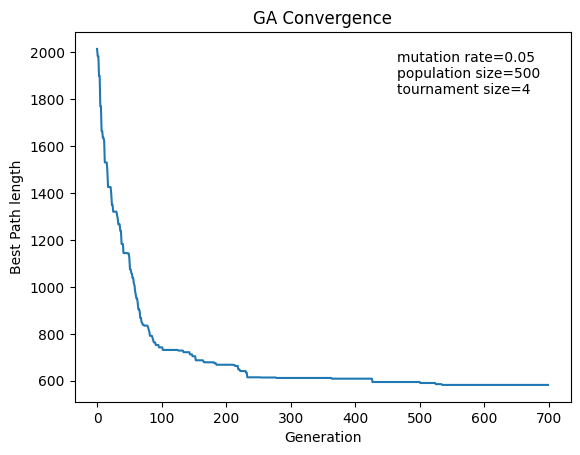

In [22]:
path_len = [1/fitness_of(c,dist_matrix) for c in results]

plt.plot(path_len)
plt.xlabel("Generation")
plt.ylabel("Best Path length")
plt.title("GA Convergence")

plt.text(
    0.65, 0.95,
    f"mutation rate={MUT_RATE}\npopulation size={POP_SIZE}\ntournament size={K}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.show()

[ 0  9  1 26 27  3 22 11 15  6 31 39 20  5 49  2 45 14 19 38 47 28 35 44
 18  4 34 37 42 29 25 48 13  8 24 12 41 36 10 21 33 17  7 23 16 46 32 30
 40 43  0]


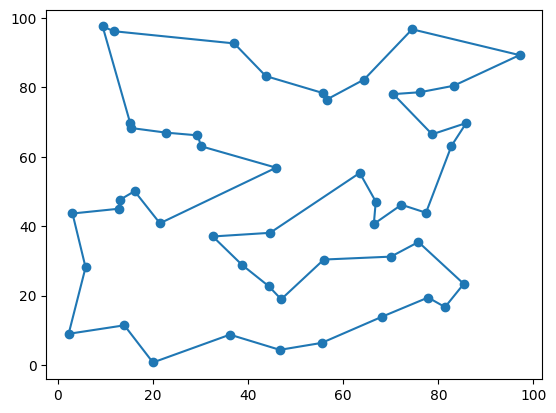

In [23]:
last_ans = results[-1].copy()
# Add start point at the end
last_ans = np.append(last_ans, last_ans[0])

print(last_ans)
ans_points = np.array([ data[idx] for idx in last_ans])

plt.plot(ans_points[:, 0], ans_points[:, 1])
plt.scatter(data[:, 0], data[:, 1])
plt.show()

In [ ]:
last_ans = results[-1].copy() 
ans_f = fitness_of(last_ans,dist_matrix)

print(f"Path length: {1/ans_f}")

Path length: 582.2923400931292
